# Exploration du dataset TMDB

Ce notebook explore les 10 000 films indexés dans Elasticsearch.
On cherche à comprendre la structure des données, leur qualité, et à tirer quelques insights métier.

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from elasticsearch import Elasticsearch

# on lit l'URL depuis les variables d'environnement
# par défaut on pointe vers le service elasticsearch du réseau Docker
ES_URL = os.getenv('ES_URL', 'http://elasticsearch:9200')
es = Elasticsearch(ES_URL)

# style global pour tous les graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Connecté :', es.ping())
print('Version   :', es.info()['version']['number'])

Connecté : True
Version   : 8.10.2


## 1. Vérification de l'ingestion

In [19]:
# on compare les deux index pour s'assurer que le pipeline a bien tourné
raw_count   = es.count(index='movies_raw')['count']
clean_count = es.count(index='movies_clean')['count']

print(f'movies_raw   : {raw_count:,} documents')
print(f'movies_clean : {clean_count:,} documents')
print(f'Écart        : {raw_count - clean_count} documents (lignes CSV malformées)')

movies_raw   : 9,972 documents
movies_clean : 9,972 documents
Écart        : 0 documents (lignes CSV malformées)


In [20]:
# on jette un oeil à quelques documents pour vérifier les champs
resp = es.search(
    index='movies_clean',
    size=5,
    query={'match_all': {}},
    sort=[{'popularity': {'order': 'desc'}}]
)

for hit in resp['hits']['hits']:
    src = hit['_source']
    print(f"{src.get('title'):<40} {src.get('release_year')}  "
          f"note: {src.get('vote_average')}  popularité: {src.get('popularity')}")

The Flash                                2023  note: 7.0  popularité: 2108.713
No Hard Feelings                         2023  note: 7.1  popularité: 1978.358
Barbie                                   2023  note: 7.5  popularité: 1976.513
Meg 2: The Trench                        2023  note: 7.0  popularité: 1730.76
Elemental                                2023  note: 7.7  popularité: 1711.569


## 2. Répartition par langue

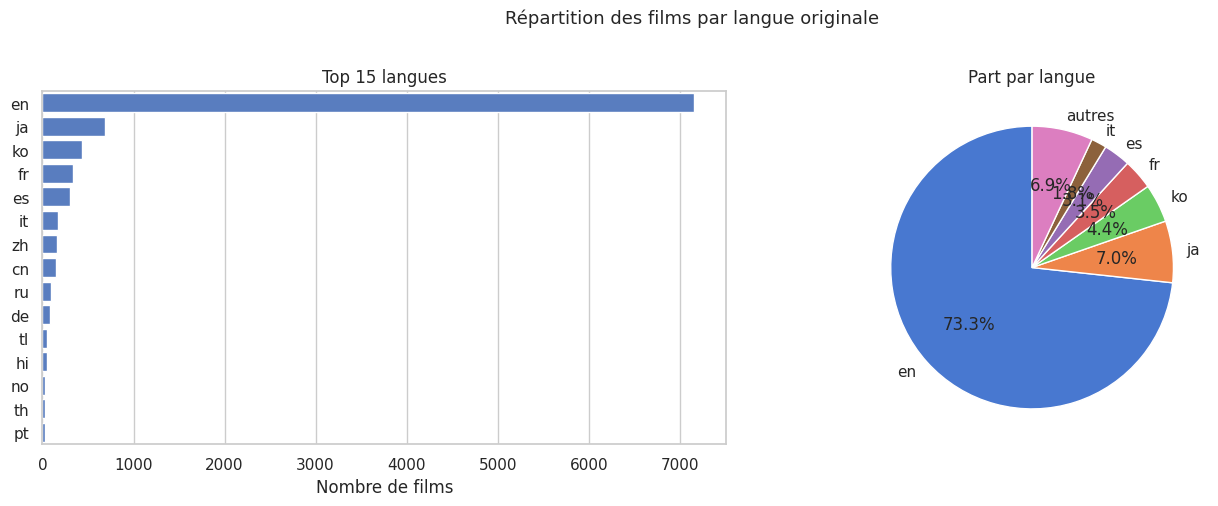

In [21]:
resp = es.search(index='movies_clean', size=0, query={'match_all': {}}, aggs={
    'par_langue': {'terms': {'field': 'original_language', 'size': 15}}
})

buckets = resp['aggregations']['par_langue']['buckets']
df_lang = pd.DataFrame(buckets).rename(columns={'key': 'langue', 'doc_count': 'nb_films'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# barplot des 15 premières langues
sns.barplot(data=df_lang, x='nb_films', y='langue', ax=axes[0])
axes[0].set_title('Top 15 langues')
axes[0].set_xlabel('Nombre de films')
axes[0].set_ylabel('')

# camembert des 6 premières + "autres" pour voir les proportions
top6    = df_lang.head(6)
autres  = df_lang.iloc[6:]['nb_films'].sum()
pie_df  = pd.concat([top6, pd.DataFrame([{'langue': 'autres', 'nb_films': autres}])], ignore_index=True)
axes[1].pie(pie_df['nb_films'], labels=pie_df['langue'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Part par langue')

plt.suptitle('Répartition des films par langue originale', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Évolution de la production par année

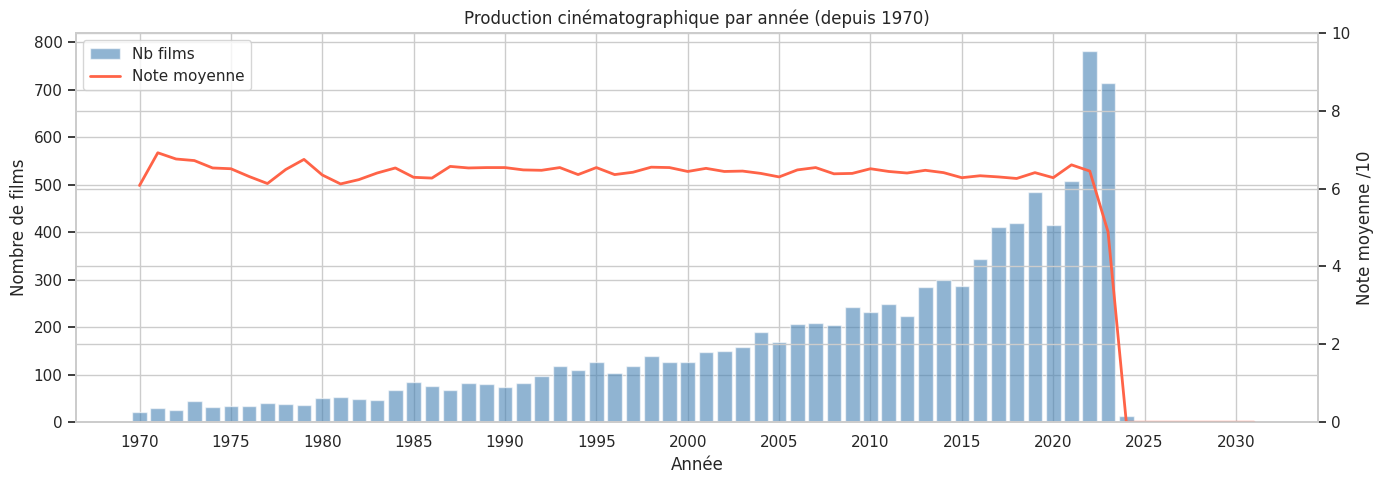

In [22]:
resp = es.search(index='movies_clean', size=0, query={'match_all': {}}, aggs={
    'par_annee': {
        'date_histogram': {
            'field': 'release_date',
            'calendar_interval': 'year',
            'format': 'yyyy'
        },
        'aggs': {
            'note_moy': {'avg': {'field': 'vote_average'}},
            'pop_moy':  {'avg': {'field': 'popularity'}}
        }
    }
})

buckets = resp['aggregations']['par_annee']['buckets']
df_annee = pd.DataFrame([{
    'annee':    int(b['key_as_string']),
    'nb_films': b['doc_count'],
    'note_moy': round(b['note_moy']['value'] or 0, 2),
    'pop_moy':  round(b['pop_moy']['value']  or 0, 2)
} for b in buckets if int(b['key_as_string']) >= 1970])

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(df_annee['annee'], df_annee['nb_films'], color='steelblue', alpha=0.6, label='Nb films')
ax1.set_xlabel('Année')
ax1.set_ylabel('Nombre de films')

ax2 = ax1.twinx()
ax2.plot(df_annee['annee'], df_annee['note_moy'], color='tomato', linewidth=2, label='Note moyenne')
ax2.set_ylabel('Note moyenne /10')
ax2.set_ylim(0, 10)

# on fusionne les légendes des deux axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Production cinématographique par année (depuis 1970)')
plt.xticks(df_annee['annee'][::5], rotation=45)
plt.tight_layout()
plt.show()

## 4. Distribution et analyse des notes

Note min    : 0.0
Note max    : 10.0
Moyenne     : 6.33
Nb de films : 9,970


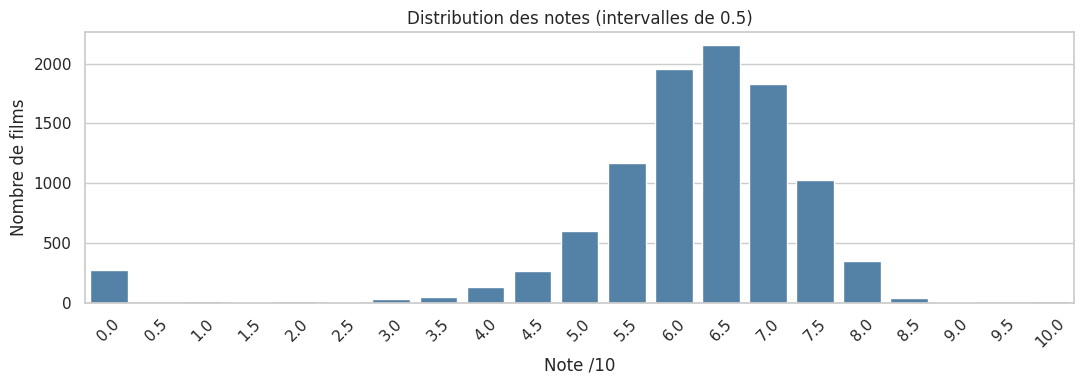

In [23]:
resp = es.search(index='movies_clean', size=0, query={'match_all': {}}, aggs={
    'distrib': {
        'histogram': {'field': 'vote_average', 'interval': 0.5}
    },
    'stats_notes': {
        'stats': {'field': 'vote_average'}
    }
})

stats = resp['aggregations']['stats_notes']
print(f"Note min    : {stats['min']}")
print(f"Note max    : {stats['max']}")
print(f"Moyenne     : {round(stats['avg'], 2)}")
print(f"Nb de films : {stats['count']:,}")

buckets  = resp['aggregations']['distrib']['buckets']
df_notes = pd.DataFrame(buckets).rename(columns={'key': 'note', 'doc_count': 'nb_films'})

plt.figure(figsize=(11, 4))
sns.barplot(data=df_notes, x='note', y='nb_films', color='steelblue')
plt.title('Distribution des notes (intervalles de 0.5)')
plt.xlabel('Note /10')
plt.ylabel('Nombre de films')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Popularité vs qualité

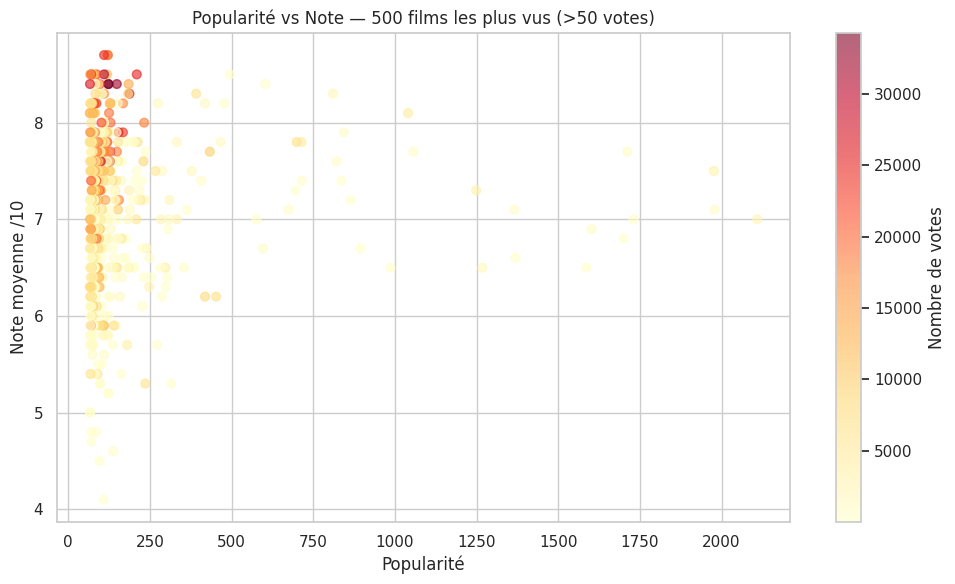

Corrélation popularité / note : 0.056


In [24]:
# on récupère les 500 films les plus populaires
# pour voir si popularité et bonne note vont souvent ensemble
resp = es.search(
    index='movies_clean',
    size=500,
    query={
        'bool': {
            'filter': [{'range': {'vote_count': {'gte': 50}}}]
        }
    },
    sort=[{'popularity': {'order': 'desc'}}],
    source=['title', 'popularity', 'vote_average', 'vote_count', 'release_year']
)

films = [hit['_source'] for hit in resp['hits']['hits']]
df_pop = pd.DataFrame(films)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_pop['popularity'],
    df_pop['vote_average'],
    c=df_pop['vote_count'],
    cmap='YlOrRd',
    alpha=0.6,
    s=40
)
plt.colorbar(scatter, label='Nombre de votes')
plt.xlabel('Popularité')
plt.ylabel('Note moyenne /10')
plt.title('Popularité vs Note — 500 films les plus vus (>50 votes)')
plt.tight_layout()
plt.show()

corr = df_pop['popularity'].corr(df_pop['vote_average'])
print(f'Corrélation popularité / note : {corr:.3f}')

## 6. Top 10 films

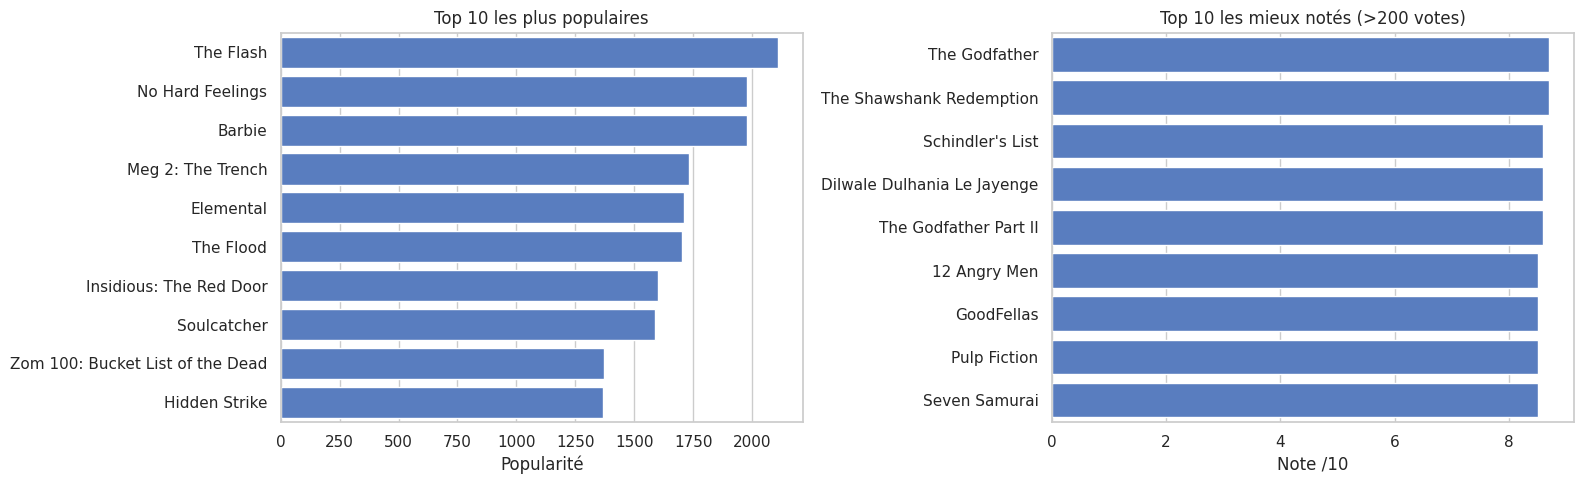

In [25]:
# top 10 par popularité
resp_pop = es.search(
    index='movies_clean', size=10,
    query={'match_all': {}},
    sort=[{'popularity': {'order': 'desc'}}],
    source=['title', 'popularity', 'vote_average', 'release_year']
)

# top 10 par note parmi les films avec assez de votes
resp_note = es.search(
    index='movies_clean', size=10,
    query={'bool': {'filter': [{'range': {'vote_count': {'gte': 200}}}]}},
    sort=[{'vote_average': {'order': 'desc'}}],
    source=['title', 'popularity', 'vote_average', 'vote_count', 'release_year']
)

df_top_pop  = pd.DataFrame([h['_source'] for h in resp_pop['hits']['hits']])
df_top_note = pd.DataFrame([h['_source'] for h in resp_note['hits']['hits']])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df_top_pop,  x='popularity',   y='title', ax=axes[0])
axes[0].set_title('Top 10 les plus populaires')
axes[0].set_xlabel('Popularité')
axes[0].set_ylabel('')

sns.barplot(data=df_top_note, x='vote_average', y='title', ax=axes[1])
axes[1].set_title('Top 10 les mieux notés (>200 votes)')
axes[1].set_xlabel('Note /10')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 7. Note moyenne par langue

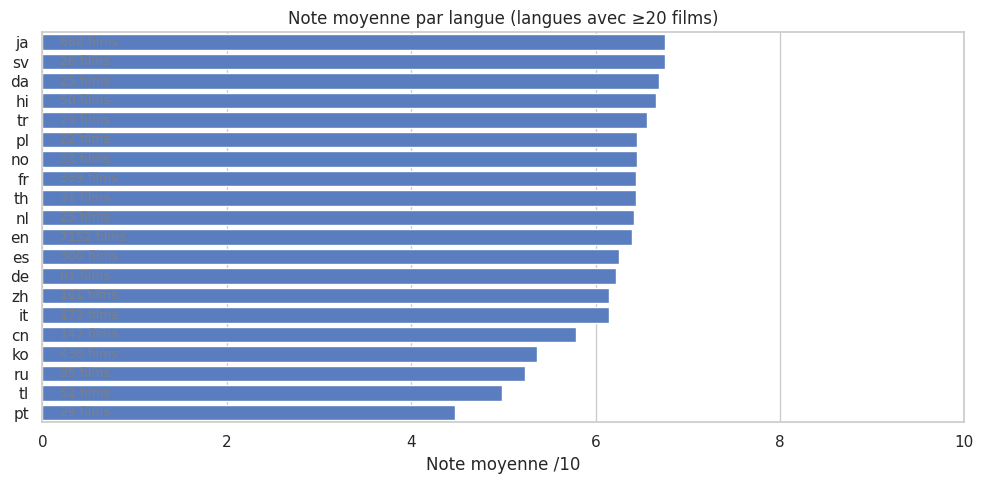

In [26]:
# on regroupe par langue et on calcule la note moyenne
# on filtre sur les langues avec au moins 20 films pour que la moyenne soit fiable
resp = es.search(index='movies_clean', size=0, query={'match_all': {}}, aggs={
    'par_langue': {
        'terms': {'field': 'original_language', 'size': 20, 'min_doc_count': 20},
        'aggs':  {'note_moy': {'avg': {'field': 'vote_average'}}}
    }
})

buckets = resp['aggregations']['par_langue']['buckets']
df_ln = pd.DataFrame([{
    'langue':   b['key'],
    'nb_films': b['doc_count'],
    'note_moy': round(b['note_moy']['value'], 2)
} for b in buckets]).sort_values('note_moy', ascending=False)

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=df_ln, x='note_moy', y='langue')

# on ajoute le nombre de films à côté de chaque barre
for i, row in df_ln.reset_index(drop=True).iterrows():
    bars.text(0.1, i, f"  {row['nb_films']} films", va='center', fontsize=9, color='gray')

plt.title('Note moyenne par langue (langues avec ≥20 films)')
plt.xlabel('Note moyenne /10')
plt.ylabel('')
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

## 8. Contrôle qualité des données

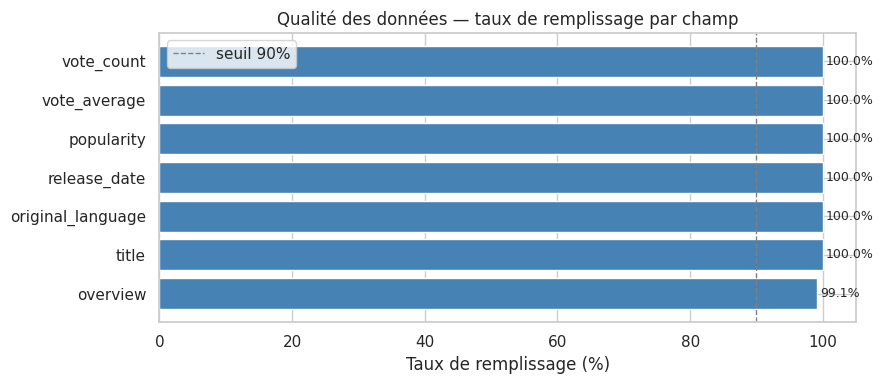

            champ  présent  manquant  taux
         overview     9880        92  99.1
            title     9970         2 100.0
original_language     9970         2 100.0
     release_date     9970         2 100.0
       popularity     9970         2 100.0
     vote_average     9970         2 100.0
       vote_count     9970         2 100.0


In [27]:
# on vérifie le taux de remplissage de chaque champ
# utile pour savoir sur quels champs on peut vraiment compter pour les analyses
total  = es.count(index='movies_clean')['count']
champs = ['title', 'original_language', 'release_date', 'popularity', 'vote_average', 'vote_count', 'overview']

rows = []
for champ in champs:
    present = es.count(index='movies_clean', query={'exists': {'field': champ}})['count']
    rows.append({
        'champ':    champ,
        'présent':  present,
        'manquant': total - present,
        'taux':     round(present / total * 100, 1)
    })

df_qualite = pd.DataFrame(rows).sort_values('taux', ascending=True)

plt.figure(figsize=(9, 4))
colors = ['tomato' if t < 90 else 'steelblue' for t in df_qualite['taux']]
plt.barh(df_qualite['champ'], df_qualite['taux'], color=colors)
plt.axvline(x=90, color='gray', linestyle='--', linewidth=1, label='seuil 90%')
plt.xlabel('Taux de remplissage (%)')
plt.title('Qualité des données — taux de remplissage par champ')
plt.xlim(0, 105)
for i, row in df_qualite.reset_index(drop=True).iterrows():
    plt.text(row['taux'] + 0.5, i, f"{row['taux']}%", va='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

print(df_qualite[['champ', 'présent', 'manquant', 'taux']].to_string(index=False))

## 9. Quality band — répartition A / B / C

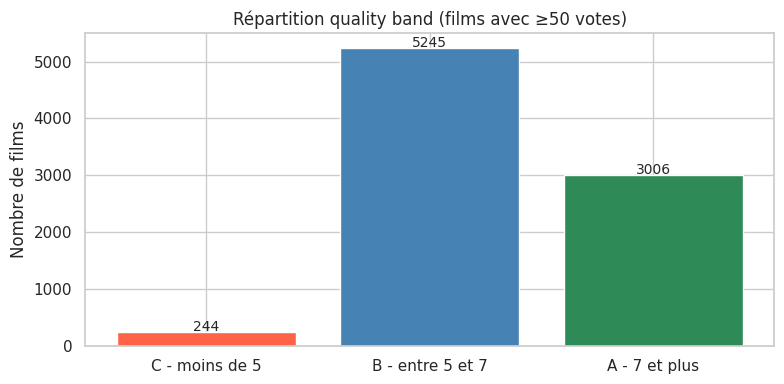

In [28]:
# on classe les films en 3 catégories selon leur note
# on filtre sur les films avec au moins 50 votes pour avoir des notes fiables
resp = es.search(
    index='movies_clean',
    size=0,
    query={'bool': {'filter': [{'range': {'vote_count': {'gte': 50}}}]}},
    aggs={
        'quality_band': {
            'range': {
                'field': 'vote_average',
                'ranges': [
                    {'key': 'C - moins de 5', 'to': 5},
                    {'key': 'B - entre 5 et 7', 'from': 5, 'to': 7},
                    {'key': 'A - 7 et plus',   'from': 7}
                ]
            }
        }
    }
)

buckets = resp['aggregations']['quality_band']['buckets']
df_qb   = pd.DataFrame(buckets).rename(columns={'key': 'catégorie', 'doc_count': 'nb_films'})

colors_qb = ['tomato', 'steelblue', 'seagreen']
plt.figure(figsize=(8, 4))
plt.bar(df_qb['catégorie'], df_qb['nb_films'], color=colors_qb)
for i, row in df_qb.iterrows():
    plt.text(i, row['nb_films'] + 20, str(row['nb_films']), ha='center', fontsize=10)
plt.title('Répartition quality band (films avec ≥50 votes)')
plt.ylabel('Nombre de films')
plt.tight_layout()
plt.show()